<a href="https://colab.research.google.com/github/ruchabhosale25/Business-case-study-21-days-challenge/blob/main/Bank_Loan_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bank Loan Analysis

Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_excel('/content/drive/MyDrive/financial_loan.xlsx')


In [8]:
df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [9]:

df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [10]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [12]:
col = ['application_type','grade','home_ownership','loan_status','purpose','sub_grade','term','verification_status']
df[col] = df[col].astype('category')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  category      
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  category      
 6   home_ownership         38576 non-null  category      
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  category      
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [14]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


##Total Loan Applications

In [15]:
total_loan_application = df['id'].shape[0]
print('No. of Applications: ',total_loan_application)

No. of Applications:  38576


##MTD Total Loan Applications

In [16]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_loan_applications = mtd_data['id'].count()
print("No. of applications for",latest_issue_date.strftime("%B %Y"),":",mtd_loan_applications)

No. of applications for December 2021 : 4314


##Total Funded Amount

In [17]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total funded amount : ${:.2f}M" . format(total_funded_amount_millions))


Total funded amount : $435.76M


##MTD Total Funded Amount

In [18]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_funded_amount = mtd_data['loan_amount'].sum()/1000000
print("MTD Funded Amount : ${:.2f}M" . format(mtd_funded_amount))

MTD Funded Amount : $53.98M


##Total Amount Received

In [19]:
total_amount_received = df['total_payment'].sum()/1000000
print("Total received amount: ${:.2f}M".format(total_amount_received))

Total received amount: $473.07M


##MTD Total Amount Received

In [20]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_received_amount = mtd_data['total_payment'].sum()/1000000
print("MTD Received Amount : ${:.2f}M" . format(mtd_received_amount))

MTD Received Amount : $58.07M


##Average Interest Rate

In [21]:
avg_int_rate = df['int_rate'].mean()*100
print("Avg Interest Rate: {:.2f}%".format(avg_int_rate))

Avg Interest Rate: 12.05%


##Avg Debt-to-income Ration (DTI)

In [22]:
avg_dti = df['dti'].mean()*100
print("Average DTI: {:.2f}%".format(avg_dti))

Average DTI: 13.33%


##Good Loan Metrics

In [23]:
good_loan = df[df['loan_status'].isin(['Current','Fully Paid'])]

total_loan_applications = df['id'].count()
good_loan_applications = good_loan['id'].count()
good_loan_funded_amount = good_loan['loan_amount'].sum()/1000000
good_loan_received_amount = good_loan['total_payment'].sum()/1000000
good_loan_percentage = good_loan_applications/total_loan_applications*100

print("Good Loan Applications: ",good_loan_applications)
print("Good loan funded amount: ${:.2f}M".format(good_loan_funded_amount))
print("Good loan received amount: ${:.2f}M".format(good_loan_received_amount))
print("Good loan percentage: {:.2f}%".format(good_loan_percentage))


Good Loan Applications:  33243
Good loan funded amount: $370.22M
Good loan received amount: $435.79M
Good loan percentage: 86.18%


##Bad Loan Applications

In [24]:
bad_loan = df[df['loan_status'].isin(['Charged Off'])]

total_loan_applications = df['id'].count()
bad_loan_applications = bad_loan['id'].count()
bad_loan_funded_amount = bad_loan['loan_amount'].sum()/1000000
bad_loan_received_amount = bad_loan['total_payment'].sum()/1000000
bad_loan_percentage = bad_loan_applications/total_loan_applications*100

print("Bad Loan Applications: ",bad_loan_applications)
print("Bad loan funded amount: ${:.2f}M".format(bad_loan_funded_amount))
print("Bad loan received amount: ${:.2f}M".format(bad_loan_received_amount))
print("Bad loan percentage: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications:  5333
Bad loan funded amount: $65.53M
Bad loan received amount: $37.28M
Bad loan percentage: 13.82%


##Monthly Trends by Issue Date for Total Funded Amount

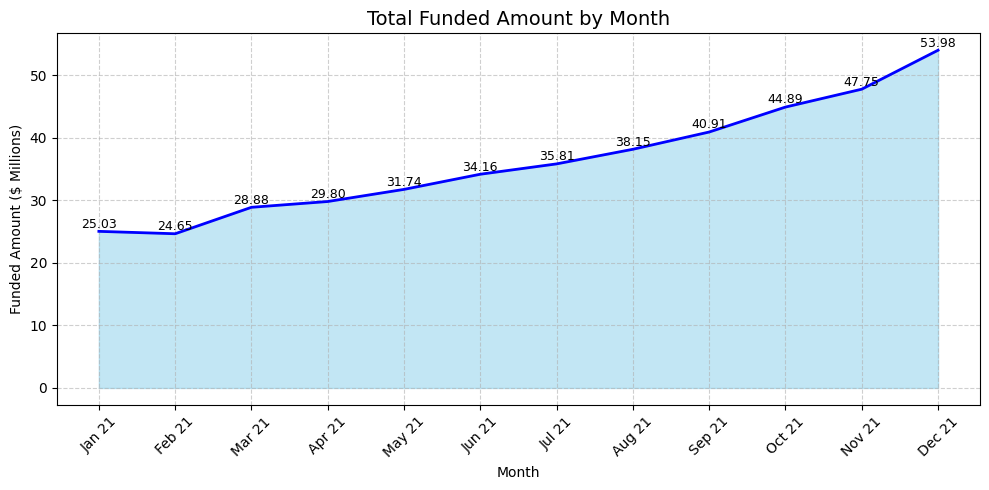

In [25]:
monthly_funded = (df.sort_values('issue_date').assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %y'))
                  .groupby('month_name',sort=False)['loan_amount'].sum()
                  .div(1000000).reset_index(name = 'loan_amount_millions'))
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color = 'blue',linewidth=2)

for i, row in monthly_funded.iterrows():
  plt.text(i,row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}", ha = 'center',
           va = 'bottom', fontsize = 9, rotation = 0, color = 'black')
plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##Monthly Trends by Issue Date for Total Received Amount

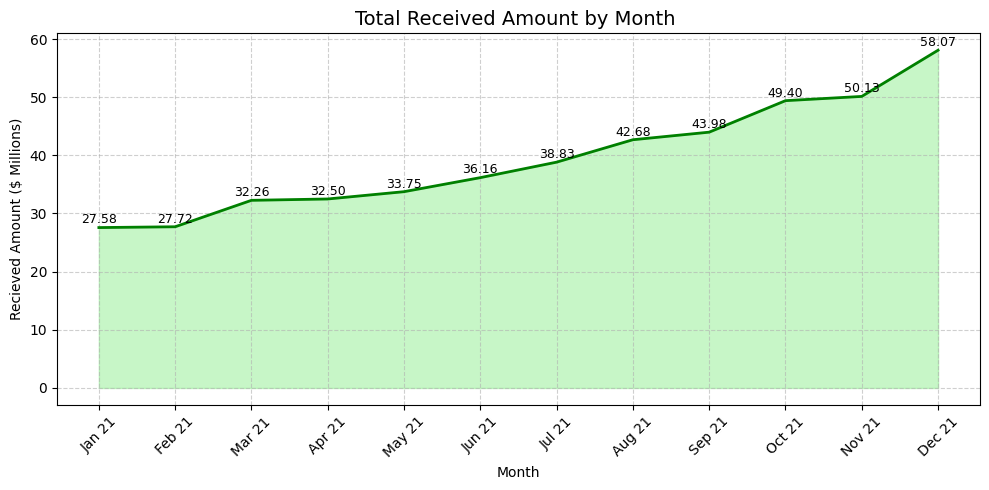

In [26]:
monthly_received = (df.sort_values('issue_date').assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %y'))
                    .groupby('month_name',sort = False)['total_payment'].sum()
                    .div(1000000).reset_index(name = 'loan_received_amount'))

plt.figure(figsize = (10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['loan_received_amount'],color= 'lightgreen',alpha = 0.5)
plt.plot(monthly_received['month_name'],monthly_received['loan_received_amount'],color = 'green',linewidth =2)
for i , row in monthly_received.iterrows():
 plt.text(i,row['loan_received_amount'] + 0.2,f"{row['loan_received_amount']:.2f}",ha = 'center',va= 'bottom',fontsize = 9)

plt.title('Total Received Amount by Month ',fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Recieved Amount ($ Millions)')
plt.xticks(ticks = range(len(monthly_received)),label= monthly_received['loan_received_amount'],rotation=45)
plt.grid(True,linestyle ='--',alpha = 0.6)
plt.tight_layout()
plt.show()

##Monthly Trends by Issue Date for Total Loan Applications

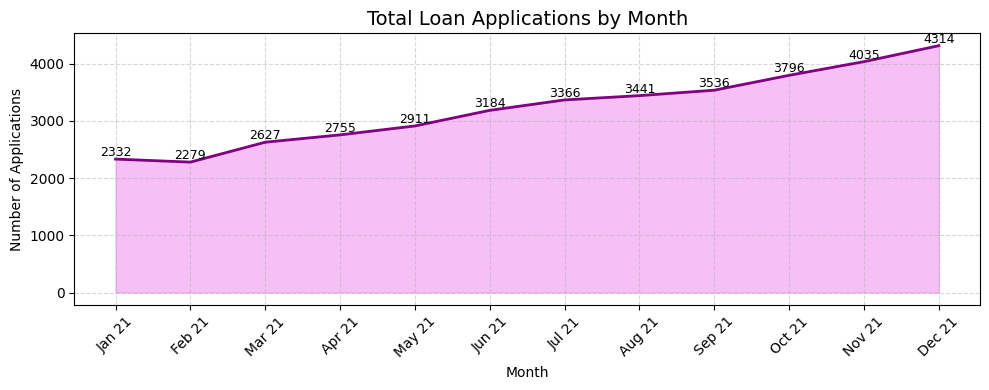

In [89]:
monthly_applications = (df.sort_values('issue_date').assign(month_name = lambda x : x['issue_date'].dt.strftime('%b %y'))
                        .groupby('month_name',sort=False)['id'].count().reset_index(name ='loan_applications'))
plt.figure(figsize = (10,4))
plt.fill_between(monthly_applications['month_name'],monthly_applications['loan_applications'],color = 'violet',alpha = 0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['loan_applications'],color = 'purple', linewidth = 2)

for i, row in monthly_applications.iterrows():
  plt.text(i,row['loan_applications']+0.5,f'{row['loan_applications']}',ha = 'center',va = 'bottom',color = 'black',fontsize = 9 )
plt.title('Total Loan Applications by Month',fontsize =14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks = range(len(monthly_applications)),label = monthly_applications['loan_applications'],rotation = 45)
plt.grid(True, linestyle= '--',alpha = 0.5)
plt.tight_layout()
plt.show()

##Regional Analysis by State for Total Funded Amount

<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-4193084934.py:11: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel("Funded Amount ($ \ '000')")


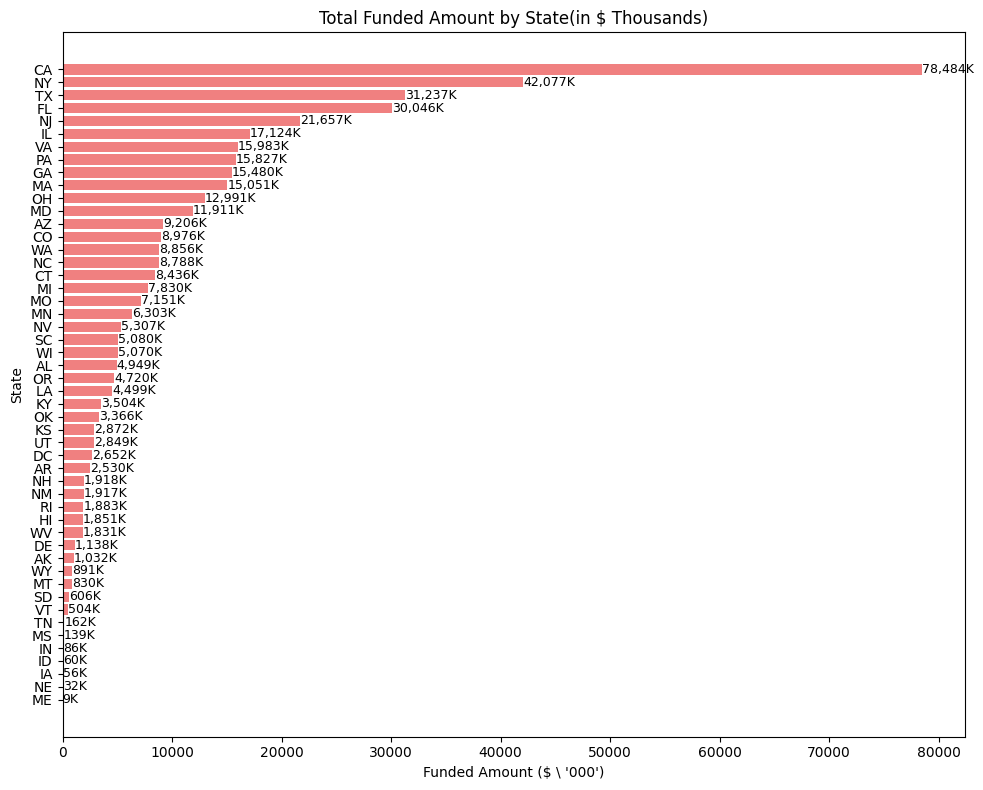

In [62]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending = True)
state_funding_thousands = state_funding/1000

plt.figure(figsize = (10,8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values,color = 'lightcoral')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 10,bar.get_y() + bar.get_height()/2,f'{width:,.0f}K' , va = 'center', fontsize = 9)
plt.title('Total Funded Amount by State(in $ Thousands)')
plt.xlabel("Funded Amount ($ \ '000')")
plt.ylabel('State')
plt.tight_layout()
plt.show()

##Loan Term Analysis by Total Funded Amount

/tmp/ipython-input-1197670499.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  term_funding_millions = df.groupby('term')['loan_amount'].sum()/1000000


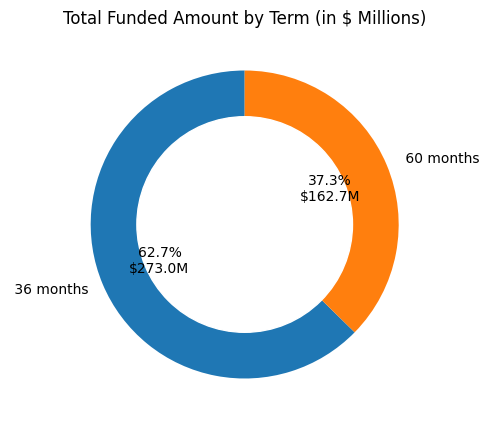

In [64]:
term_funding_millions = df.groupby('term')['loan_amount'].sum()/1000000
plt.figure(figsize=(5,5))
plt.pie(term_funding_millions,labels =term_funding_millions.index,
        autopct = lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
        startangle = 90,
        wedgeprops = {'width':0.4})
plt.gca().add_artist(plt.Circle((0,0),0.70,color = 'white'))
plt.title('Total Funded Amount by Term (in $ Millions)')
plt.show()

##Emplyee Length by Total Funded Amount


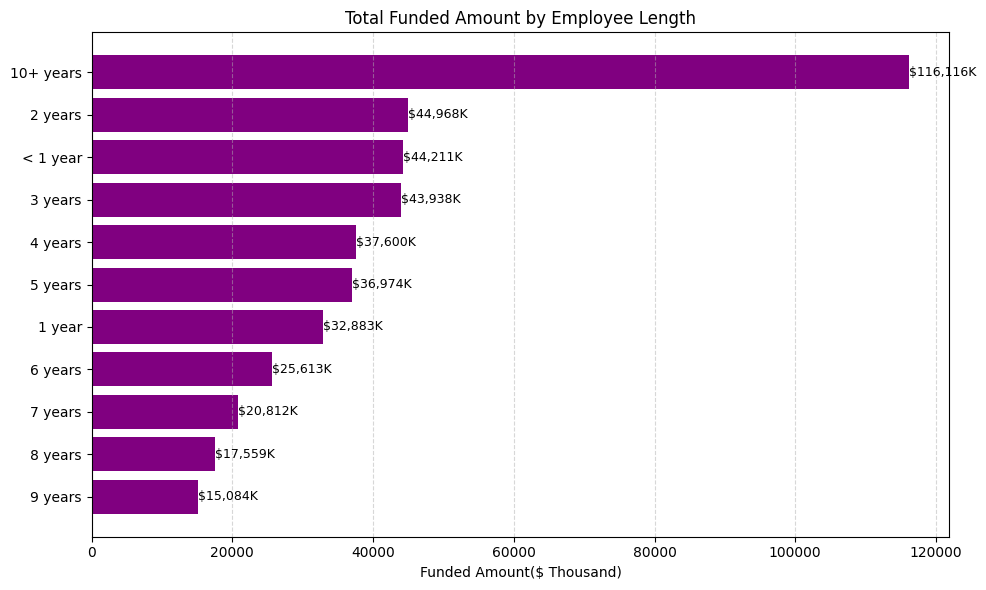

In [82]:
emp_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize =(10,6))
bars = plt.barh(emp_funding_thousands.index,emp_funding_thousands,color = 'purple')

for bar in bars:
  width = bar.get_width()
  plt.text(width +5, bar.get_y() + bar.get_height()/2,
           f"${width:,.0f}K",va='center',fontsize=9)
plt.xlabel("Funded Amount($ Thousand)")
plt.title("Total Funded Amount by Employee Length")
plt.grid(axis='x',linestyle ='--',alpha = 0.5)
plt.tight_layout()
plt.show()

##Loan Purpose by Total Funded Amount

/tmp/ipython-input-2451034288.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values()/1000000)


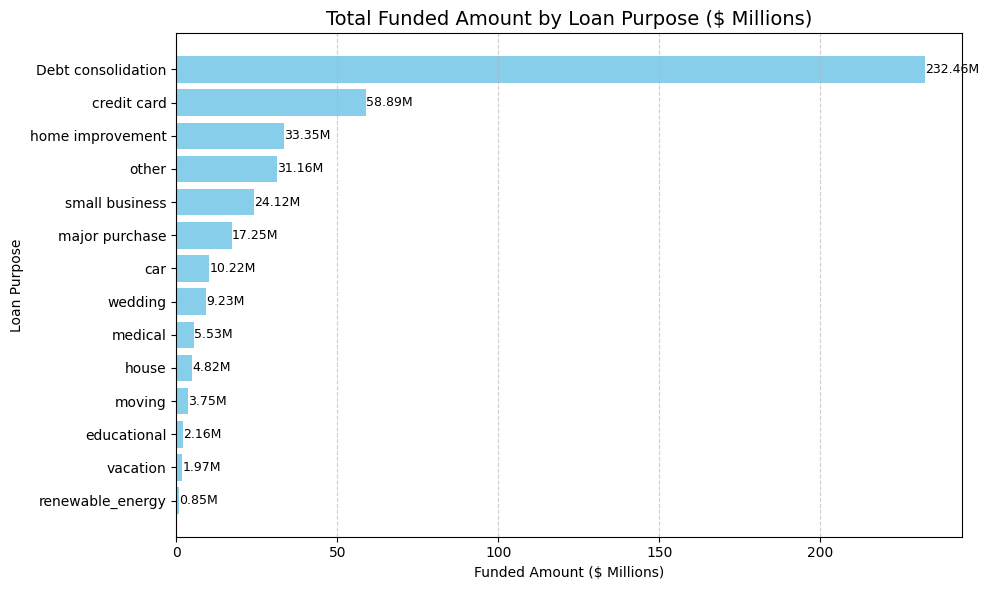

In [84]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values()/1000000)

plt.figure(figsize = (10,6))
bars = plt.barh(purpose_funding_millions.index,purpose_funding_millions.values,color = 'skyblue')

for bar in bars:
  width = bar.get_width()
  plt.text(width +0.1,bar.get_y() +bar.get_height()/2,
           f'{width:.2f}M',va = 'center',fontsize = 9)
plt.title('Total Funded Amount by Loan Purpose ($ Millions)',fontsize = 14)
plt.xlabel('Funded Amount ($ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis = 'x',linestyle = '--',alpha = 0.6)
plt.tight_layout()
plt.show()

##Home Ownership by Total Funded Amount

In [86]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount']/1000000

fig = px.treemap(
    home_funding,
    path = ['home_ownership'],
    values ='loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale = 'Blues',
    title = 'Total Funded Amount by Home Ownership($ Millions)'
)
fig.show()

/tmp/ipython-input-2595078571.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
